### MNIST classifier using alternating projections (batched)

In [16]:
%load_ext autoreload
%autoreload 2
import matplotlib
matplotlib.use('Agg')

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
sys.path.append(os.path.abspath(os.getcwd()))

import jax.numpy as jnp
import jax.random as random
import tools.projections as projections
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import jax
jax.config.update("jax_enable_x64", True)
import numpy as np
import optax

from torchvision.datasets import MNIST
from torch.utils.data import DataLoader

rand_key = random.key(42)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
@jax.jit
def leakyReluActivationVectorized(x, W, z, slope=0.1):
    H = W @ x
    x_1 = jnp.clip((H + slope * z) / (1.0 + slope * slope), a_max=0)
    y_1 = slope * x_1
    dist_1 = (H - x_1)**2 + (z - y_1)**2
    x_2 = jnp.clip((H + z) / 2.0, a_min=0)
    y_2 = x_2
    dist_2 = (H - x_2)**2 + (z - y_2)**2
    new_H = jnp.where(dist_1 < dist_2, x_1, x_2)
    new_z = jnp.where(dist_1 < dist_2, y_1, y_2)
    return new_H, W, new_z

In [18]:
### Setup problem
NUM_CLASSES   = 10
HIDDEN_WIDTH  = 128
IN_FEATURES   = 784
BATCH_SIZE    = 64
BACKWARDS_PASSES = 10
NUM_EPOCHS    = 1
DELTA         = 1.0
MNIST_MEAN, MNIST_STD = 0.1307, 0.3081

def load_mnist(batch_size=64, data_dir="./dataset"):
    def collate_fn(batch):
        images, labels = zip(*batch)
        x = np.array(images, dtype=np.float32) / 255.0
        y = np.array(labels, dtype=np.int64)
        if x.ndim == 3: x = x[..., None]
        x = (x - MNIST_MEAN) / MNIST_STD
        return x, y
    train_ds = MNIST(data_dir, train=True, download=True)
    test_ds  = MNIST(data_dir, train=False, download=True)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, drop_last=True)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, drop_last=False)
    return train_loader, test_loader

def prepare_batch(x_np, y_np):
    batch = x_np.shape[0]
    x_in = jnp.array(x_np.reshape(batch, -1).T, dtype=jnp.float32)
    y_target = jax.nn.one_hot(jnp.array(y_np), NUM_CLASSES).T
    return x_in, y_target

def forward_pass(W0, W1, x_in, y_target):
    x_hidden = W0 @ x_in
    h_hidden = jnp.where(x_hidden > 0, x_hidden, 0.1 * x_hidden)
    x_out    = W1 @ h_hidden
    err_pos = jnp.where(y_target == 1, jnp.where(x_out < DELTA, (x_out - DELTA)**2, 0.0), 0.0)
    err_neg = jnp.where(y_target == 0, jnp.where(x_out > 0, x_out**2, 0.0), 0.0)
    return err_pos + err_neg, x_hidden, h_hidden, x_out

def compute_accuracy(W0, W1, loader, max_batches=None):
    correct, total = 0, 0
    for i, (x_np, y_np) in enumerate(loader):
        if max_batches is not None and i >= max_batches: break
        x_in, y_target = prepare_batch(x_np, y_np)
        _, _, _, x_out = forward_pass(W0, W1, x_in, y_target)
        correct += int(jnp.sum(jnp.argmax(x_out, axis=0) == jnp.array(y_np)))
        total += len(y_np)
    return correct / total if total > 0 else 0.0

train_loader, test_loader = load_mnist(BATCH_SIZE)

## (baseline) Cyclic projections

In [19]:
### Run Cyclic Projections Experiment (batched MNIST)
results = []
key = rand_key
key, k1, k2 = random.split(key, 3)
W0 = random.normal(k1, (HIDDEN_WIDTH, IN_FEATURES)) * 0.01
W1 = random.normal(k2, (NUM_CLASSES, HIDDEN_WIDTH)) * 0.01

global_step = 0
test_iter = iter(test_loader)
for epoch in range(NUM_EPOCHS):
    epoch_errors = []
    for batch_idx, (x_np, y_np) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")):
        x_in, y_target = prepare_batch(x_np, y_np)
        batchError, x_hidden, h_hidden, x_out = forward_pass(W0, W1, x_in, y_target)

        for bp in range(BACKWARDS_PASSES):
            x_out, _, _ = projections.classifierOutputVector(x_out, jnp.eye(NUM_CLASSES), y_target)
            h_hidden, W1, x_out = projections.matmul_proj(h_hidden, W1, x_out)
            x_hidden, _, h_hidden = leakyReluActivationVectorized(x_hidden, jnp.eye(HIDDEN_WIDTH), h_hidden)
            x_in, W0, x_hidden = projections.matmul_proj_fixed_X(x_in, W0, x_hidden)

        batchError, _, _, x_out_log = forward_pass(W0, W1, x_in, y_target)
        current_error = float(jnp.mean(batchError))
        train_acc = float(jnp.mean(jnp.argmax(x_out_log, axis=0) == jnp.array(y_np)))

        test_acc = compute_accuracy(W0, W1, test_loader)
        epoch_errors.append(current_error)
        results.append({"Epoch": epoch, "Step": global_step, "Error": current_error, "TrainAcc": train_acc, "ValAcc": test_acc})
        global_step += 1

    test_acc = compute_accuracy(W0, W1, test_loader)
    print(f"  Epoch {epoch+1} — Avg Error: {np.mean(epoch_errors):.4e}  Vall Acc: {test_acc:.4f}")
print(f"Final Test Accuracy: {compute_accuracy(W0, W1, test_loader):.4f}")

Epoch 1/1: 100%|██████████| 937/937 [03:55<00:00,  3.98it/s]


  Epoch 1 — Avg Error: 1.3928e-02  Vall Acc: 0.9408
Final Test Accuracy: 0.9408


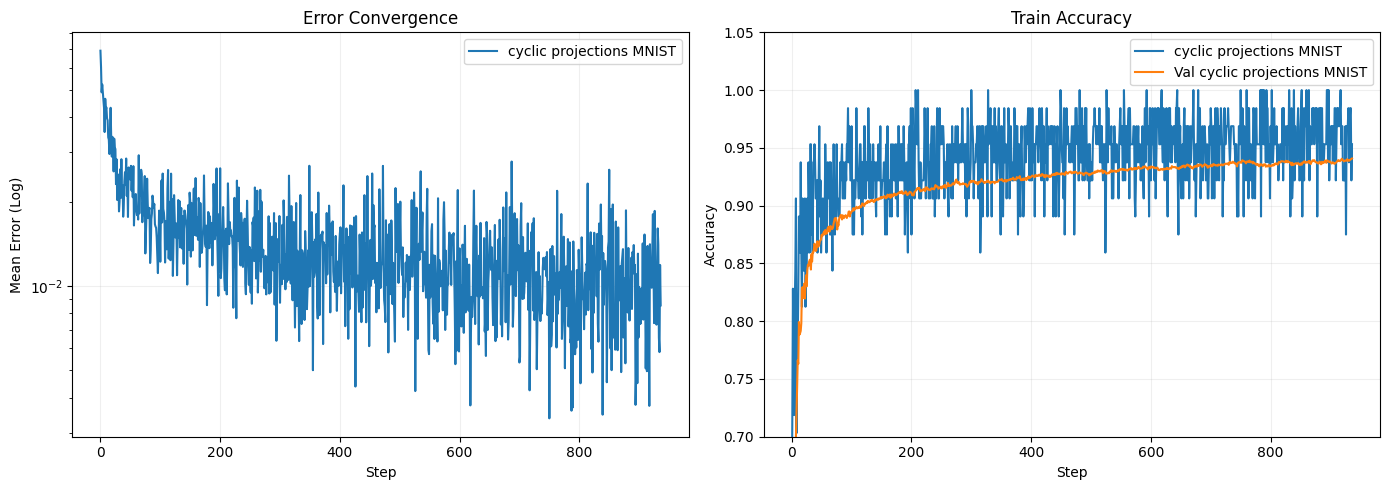

In [20]:
%matplotlib inline
### Visualize Results
df_pure = pd.DataFrame(results.copy())
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=df_pure, x="Step", y="Error", label='cyclic projections MNIST', ax=ax1)
ax1.set_yscale('log'); ax1.set_title("Error Convergence"); ax1.set_ylabel("Mean Error (Log)"); ax1.grid(True, alpha=0.2)
sns.lineplot(data=df_pure, x="Step", y="TrainAcc", label='cyclic projections MNIST', ax=ax2)
sns.lineplot(data=df_pure, x="Step", y="ValAcc", label='Val cyclic projections MNIST', ax=ax2)
ax2.set_ylim(0.7, 1.05); ax2.set_title("Train Accuracy"); ax2.set_ylabel("Accuracy"); ax2.grid(True, alpha=0.2)
fig.tight_layout(); fig.savefig('mnist_cyclic_pure.png', dpi=150)

## forward proj proj (weights)

In [ ]:
### Run Nonlinear Relaxed Projections (weights only)
train_loader, test_loader = load_mnist(BATCH_SIZE)
results = []
key = rand_key
key, k1, k2 = random.split(key, 3)
W0 = random.normal(k1, (HIDDEN_WIDTH, IN_FEATURES)) * 0.01
W1 = random.normal(k2, (NUM_CLASSES, HIDDEN_WIDTH)) * 0.01
optim_state_W0 = optim_W0.init(W0)
optim_state_W1 = optim_W1.init(W1)

global_step = 0
test_iter = iter(test_loader)
for epoch in range(NUM_EPOCHS):
    epoch_errors = []
    for batch_idx, (x_np, y_np) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")):
        x_in, y_target = prepare_batch(x_np, y_np)
        batchError, x_hidden, h_hidden, x_out = forward_pass(W0, W1, x_in, y_target)

        for bp in range(BACKWARDS_PASSES):
            x_in, W0, x_hidden = projections.matmul_proj_fixed_X(x_in, W0, x_hidden)
            x_hidden, _, h_hidden = leakyReluActivationVectorized(x_hidden, jnp.eye(HIDDEN_WIDTH), h_hidden)
            h_hidden, W1, x_out = projections.matmul_proj(h_hidden, W1, x_out)

            x_out, _, _ = projections.classifierOutputVector(x_out, jnp.eye(NUM_CLASSES), y_target)
            h_hidden, W1, x_out = projections.matmul_proj(h_hidden, W1, x_out)

            x_hidden, _, h_hidden = leakyReluActivationVectorized(x_hidden, jnp.eye(HIDDEN_WIDTH), h_hidden)
            x_in, W0, x_hidden = projections.matmul_proj_fixed_X(x_in, W0, x_hidden)

        batchError, _, _, x_out_log = forward_pass(W0, W1, x_in, y_target)
        current_error = float(jnp.mean(batchError))
        train_acc = float(jnp.mean(jnp.argmax(x_out_log, axis=0) == jnp.array(y_np)))
        print(train_acc)
        val_acc = compute_accuracy(W0, W1, test_loader)
        epoch_errors.append(current_error)
        results.append({"Epoch": epoch, "Step": global_step, "Error": current_error, "TrainAcc": train_acc, "Val Acc": val_acc})
        global_step += 1

    val_acc = compute_accuracy(W0, W1, test_loader)
    print(f"  Epoch {epoch+1} — Avg Error: {np.mean(epoch_errors):.4e}  Val Acc: {val_acc:.4f}")
print(f"Final Test Accuracy: {compute_accuracy(W0, W1, test_loader):.4f}")

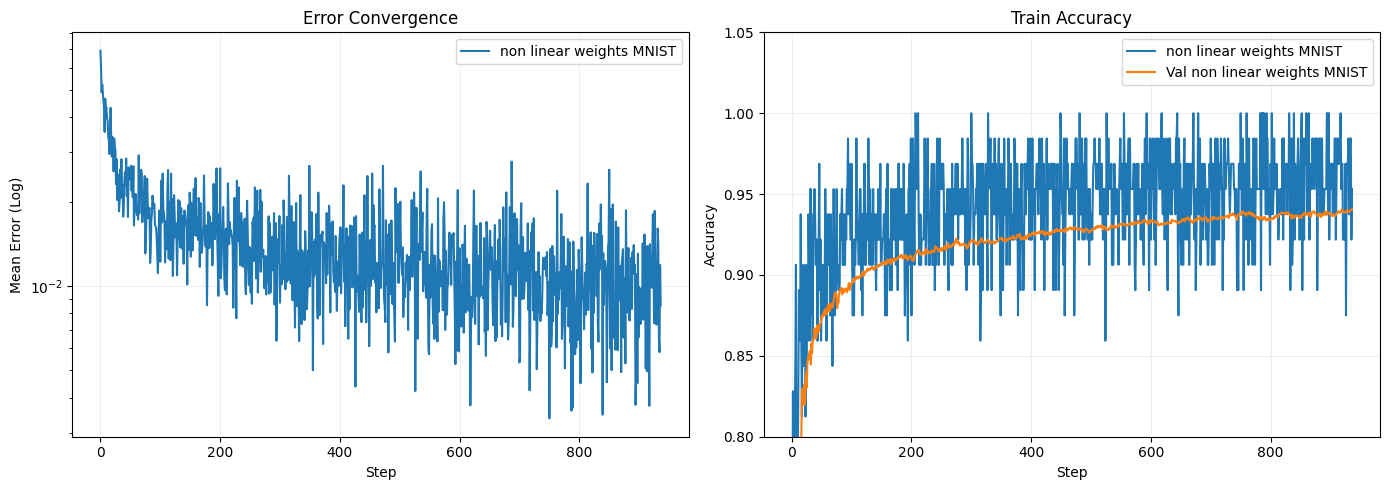

In [24]:
%matplotlib inline

### Visualize Results
df_non_linear_weights = pd.DataFrame(results.copy())
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=df_non_linear_weights, x="Step", y="Error", label='non linear weights MNIST', ax=ax1)
ax1.set_yscale('log'); ax1.set_title("Error Convergence"); ax1.set_ylabel("Mean Error (Log)"); ax1.grid(True, alpha=0.2)
sns.lineplot(data=df_non_linear_weights, x="Step", y="TrainAcc", label='non linear weights MNIST', ax=ax2)
sns.lineplot(data=df_non_linear_weights, x="Step", y="ValAcc", label='Val non linear weights MNIST', ax=ax2)
ax2.set_ylim(0.8, 1.05); ax2.set_title("Train Accuracy"); ax2.set_ylabel("Accuracy"); ax2.grid(True, alpha=0.2)
fig.tight_layout(); fig.savefig('mnist_cyclic_relaxed_weights.png', dpi=150)

## proj proj 1 step

In [ ]:
import optax

optim_W0 = optax.adam(learning_rate=0.001)
optim_W1 = optax.adam(learning_rate=0.001)


In [ ]:
### Run Nonlinear Relaxed Projections (weights only)
train_loader, test_loader = load_mnist(BATCH_SIZE)
results = []
key = rand_key
key, k1, k2 = random.split(key, 3)
W0 = random.normal(k1, (HIDDEN_WIDTH, IN_FEATURES)) * 0.01
W1 = random.normal(k2, (NUM_CLASSES, HIDDEN_WIDTH)) * 0.01
optim_state_W0 = optim_W0.init(W0)
optim_state_W1 = optim_W1.init(W1)

global_step = 0
test_iter = iter(test_loader)
for epoch in range(NUM_EPOCHS):
    epoch_errors = []
    for batch_idx, (x_np, y_np) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")):
        x_in, y_target = prepare_batch(x_np, y_np)
        batchError, x_hidden, h_hidden, x_out = forward_pass(W0, W1, x_in, y_target)

        x_in, W0, x_hidden = projections.matmul_proj_fixed_X(x_in, W0, x_hidden)
        x_hidden, _, h_hidden = leakyReluActivationVectorized(x_hidden, jnp.eye(HIDDEN_WIDTH), h_hidden)
        h_hidden, W1, x_out = projections.matmul_proj(h_hidden, W1, x_out)

        x_out, _, _ = projections.classifierOutputVector(x_out, jnp.eye(NUM_CLASSES), y_target)
        h_hidden, W1, x_out = projections.matmul_proj(h_hidden, W1, x_out)

        x_hidden, _, h_hidden = leakyReluActivationVectorized(x_hidden, jnp.eye(HIDDEN_WIDTH), h_hidden)
        x_in, W0, x_hidden = projections.matmul_proj_fixed_X(x_in, W0, x_hidden)

        batchError, _, _, x_out_log = forward_pass(W0, W1, x_in, y_target)
        current_error = float(jnp.mean(batchError))
        train_acc = float(jnp.mean(jnp.argmax(x_out_log, axis=0) == jnp.array(y_np)))
        print(train_acc)
        val_acc = compute_accuracy(W0, W1, test_loader)
        epoch_errors.append(current_error)
        results.append({"Epoch": epoch, "Step": global_step, "Error": current_error, "TrainAcc": train_acc, "Val Acc": val_acc})
        global_step += 1

    val_acc = compute_accuracy(W0, W1, test_loader)
    print(f"  Epoch {epoch+1} — Avg Error: {np.mean(epoch_errors):.4e}  Val Acc: {val_acc:.4f}")
print(f"Final Test Accuracy: {compute_accuracy(W0, W1, test_loader):.4f}")

In [ ]:
### Run Nonlinear Relaxed Projections (full)
train_loader, test_loader = load_mnist(BATCH_SIZE)
results = []
key = rand_key
key, k1, k2 = random.split(key, 3)
W0 = random.normal(k1, (HIDDEN_WIDTH, IN_FEATURES)) * 0.01
W1 = random.normal(k2, (NUM_CLASSES, HIDDEN_WIDTH)) * 0.01
optim_state_W0 = optim_W0.init(W0)
optim_state_W1 = optim_W1.init(W1)

global_step = 0
test_iter = iter(test_loader)
for epoch in range(NUM_EPOCHS):
    epoch_errors = []
    for batch_idx, (x_np, y_np) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")):
        x_in, y_target = prepare_batch(x_np, y_np)
        batchError, x_hidden, h_hidden, x_out = forward_pass(W0, W1, x_in, y_target)
        optim_state_x_hidden = optim_x_hidden.init(x_hidden)
        optim_state_h_hidden = optim_h_hidden.init(h_hidden)

        for bp in range(BACKWARDS_PASSES):
            x_out, _, _ = projections.classifierOutputVector(x_out, jnp.eye(NUM_CLASSES), y_target)

            h_hidden_proj, w1_proj, x_out = projections.matmul_proj(h_hidden, W1, x_out)
            pseudo_grads_W1 = W1 - w1_proj
            updates_W1, optim_state_W1 = optim_W1.update(pseudo_grads_W1, optim_state_W1, W1)
            W1 = optax.apply_updates(W1, updates_W1)
            pseudo_grads_h = h_hidden - h_hidden_proj
            updates_h, optim_state_h_hidden = optim_h_hidden.update(pseudo_grads_h, optim_state_h_hidden, h_hidden)
            h_hidden = optax.apply_updates(h_hidden, updates_h)

            x_hidden_proj, _, h_hidden_proj = leakyReluActivationVectorized(x_hidden, jnp.eye(HIDDEN_WIDTH), h_hidden)
            pseudo_grads_h = h_hidden - h_hidden_proj
            updates_h, optim_state_h_hidden = optim_h_hidden.update(pseudo_grads_h, optim_state_h_hidden, h_hidden)
            h_hidden = optax.apply_updates(h_hidden, updates_h)
            pseudo_grads_x = x_hidden - x_hidden_proj
            updates_x, optim_state_x_hidden = optim_x_hidden.update(pseudo_grads_x, optim_state_x_hidden, x_hidden)
            x_hidden = optax.apply_updates(x_hidden, updates_x)

            x_in, w0_proj, x_hidden_proj = projections.matmul_proj_fixed_X(x_in, W0, x_hidden)
            pseudo_grads_W0 = W0 - w0_proj
            updates_W0, optim_state_W0 = optim_W0.update(pseudo_grads_W0, optim_state_W0, W0)
            W0 = optax.apply_updates(W0, updates_W0)
            pseudo_grads_x = x_hidden - x_hidden_proj
            updates_x, optim_state_x_hidden = optim_x_hidden.update(pseudo_grads_x, optim_state_x_hidden, x_hidden)
            x_hidden = optax.apply_updates(x_hidden, updates_x)

        batchError, _, _, x_out_log = forward_pass(W0, W1, x_in, y_target)
        current_error = float(jnp.mean(batchError))
        train_acc = float(jnp.mean(jnp.argmax(x_out_log, axis=0) == jnp.array(y_np)))

        val_acc = compute_accuracy(W0, W1, test_loader)
        epoch_errors.append(current_error)
        results.append({"Epoch": epoch, "Step": global_step, "Error": current_error, "TrainAcc": train_acc, "ValAcc": val_acc})
        global_step += 1

    test_acc = compute_accuracy(W0, W1, test_loader)
    print(f"  Epoch {epoch+1} — Avg Error: {np.mean(epoch_errors):.4e}  Test Acc: {test_acc:.4f}")
print(f"Final Test Accuracy: {compute_accuracy(W0, W1, test_loader):.4f}")

In [ ]:
### Visualize Results
df_non_linear_full = pd.DataFrame(results.copy())
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=df_non_linear_full, x="Step", y="Error", label='non linear full MNIST', ax=ax1)
ax1.set_yscale('log'); ax1.set_title("Error Convergence"); ax1.set_ylabel("Mean Error (Log)"); ax1.grid(True, alpha=0.2)
sns.lineplot(data=df_non_linear_full, x="Step", y="TrainAcc", label='non linear full MNIST', ax=ax2)
sns.lineplot(data=df_non_linear_full, x="Step", y="ValAcc", label='Val non linear full MNIST', ax=ax2)
ax2.set_ylim(0, 1.05); ax2.set_title("Train Accuracy"); ax2.set_ylabel("Accuracy"); ax2.grid(True, alpha=0.2)
fig.tight_layout(); fig.savefig('mnist_cyclic_relaxed_full.png', dpi=150)

## Compare all 3 approaches

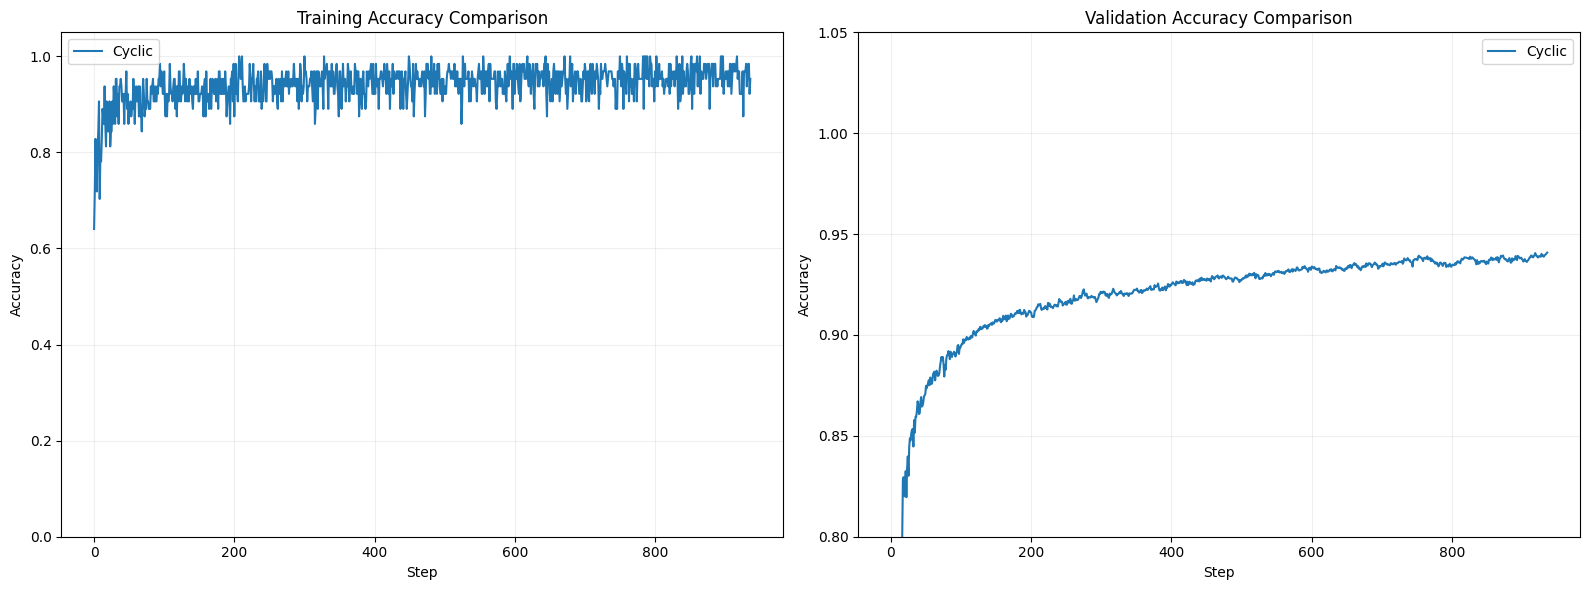

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

if 'df_pure' in locals():
    sns.lineplot(data=df_pure, x="Step", y="TrainAcc", label='Cyclic', ax=ax1)
    sns.lineplot(data=df_pure, x="Step", y="ValAcc", label='Cyclic', ax=ax2)
if 'df_non_linear_weights' in locals():
    sns.lineplot(data=df_non_linear_weights, x="Step", y="TrainAcc", label='Relaxed Weights', ax=ax1)
    sns.lineplot(data=df_non_linear_weights, x="Step", y="ValAcc", label='Relaxed Weights', ax=ax2)
if 'df_non_linear_full' in locals():
    sns.lineplot(data=df_non_linear_full, x="Step", y="TrainAcc", label='Relaxed Full', ax=ax1)
    sns.lineplot(data=df_non_linear_full, x="Step", y="ValAcc", label='Relaxed Full', ax=ax2)

ax1.set_title("Training Accuracy Comparison")
ax1.set_ylabel("Accuracy")
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.2)

ax2.set_title("Validation Accuracy Comparison")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0.8, 1.05)
ax2.grid(True, alpha=0.2)

fig.tight_layout()
fig.savefig('mnist_cyclic_comparison.png', dpi=150)